In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
import kagglehub
import os

# Download latest version
path = kagglehub.dataset_download("dgomonov/new-york-city-airbnb-open-data")

print("Path to dataset files:", path)

df = pd.read_csv(os.path.join(path,"AB_NYC_2019.csv"))
df.head()

Using Colab cache for faster access to the 'new-york-city-airbnb-open-data' dataset.
Path to dataset files: /kaggle/input/new-york-city-airbnb-open-data


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

In [5]:
df.columns

Index(['id', 'name', 'host_id', 'host_name', 'neighbourhood_group',
       'neighbourhood', 'latitude', 'longitude', 'room_type', 'price',
       'minimum_nights', 'number_of_reviews', 'last_review',
       'reviews_per_month', 'calculated_host_listings_count',
       'availability_365'],
      dtype='object')

In [6]:
df.shape

(48895, 16)

In [7]:
df.describe()

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,4.889500e+04,4.889500e+04,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,38843.000000,48895.000000,48895.000000
mean,1.901714e+07,6.762001e+07,40.728949,-73.952170,152.720687,7.029962,23.274466,1.373221,7.143982,112.781327
std,1.098311e+07,7.861097e+07,0.054530,0.046157,240.154170,20.510550,44.550582,1.680442,32.952519,131.622289
min,2.539000e+03,2.438000e+03,40.499790,-74.244420,0.000000,1.000000,0.000000,0.010000,1.000000,0.000000
25%,9.471945e+06,7.822033e+06,40.690100,-73.983070,69.000000,1.000000,1.000000,0.190000,1.000000,0.000000
50%,1.967728e+07,3.079382e+07,40.723070,-73.955680,106.000000,3.000000,5.000000,0.720000,1.000000,45.000000
75%,2.915218e+07,1.074344e+08,40.763115,-73.936275,175.000000,5.000000,24.000000,2.020000,2.000000,227.000000
max,3.648724e+07,2.743213e+08,40.913060,-73.712990,10000.000000,1250.000000,629.000000,58.500000,327.000000,365.000000


In [8]:
df.isnull().sum()

,0
id,0
name,16
host_id,0
host_name,21
neighbourhood_group,0
neighbourhood,0
latitude,0
longitude,0
room_type,0
price,0


In [9]:
df['room_type'].value_counts()

,count
room_type,
Entire home/apt,25409
Private room,22326
Shared room,1160


<Axes: xlabel='room_type', ylabel='count'>

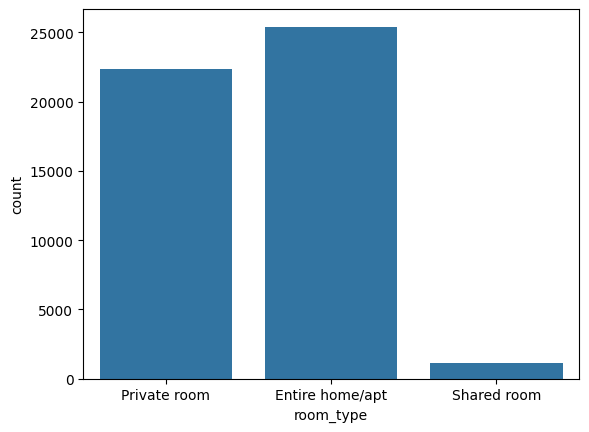

In [10]:
sns.countplot(x = 'room_type' , data = df)


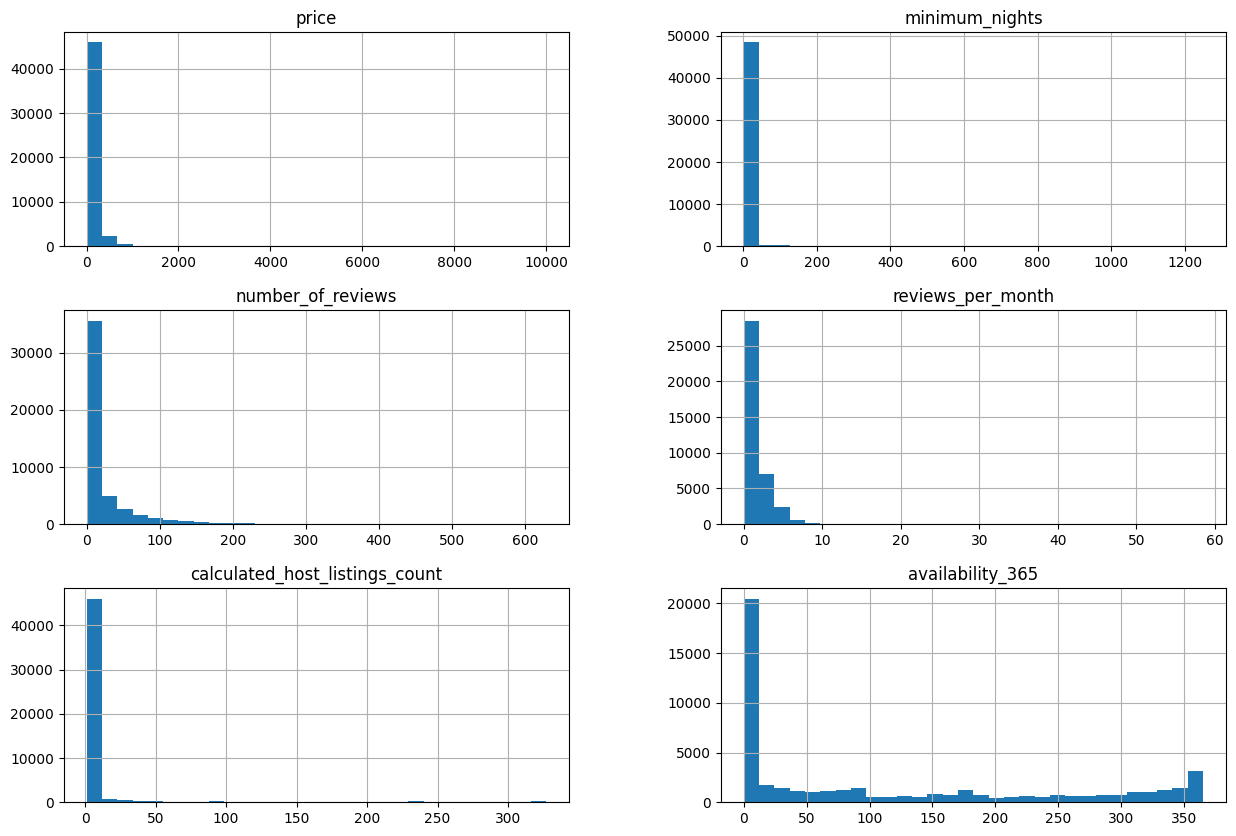

In [11]:
numerical_col = ["price" , "minimum_nights" , "number_of_reviews" ,
                 "reviews_per_month" , "calculated_host_listings_count" ,
                 "availability_365"]

df[numerical_col].hist(bins = 30 , figsize = (15,10))
plt.show()


<Axes: xlabel='neighbourhood_group', ylabel='count'>

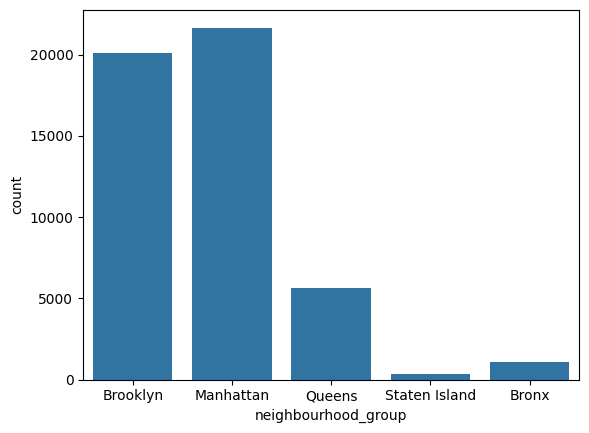

In [12]:
sns.countplot(data = df , x = 'neighbourhood_group')

<Axes: xlabel='room_type', ylabel='price'>

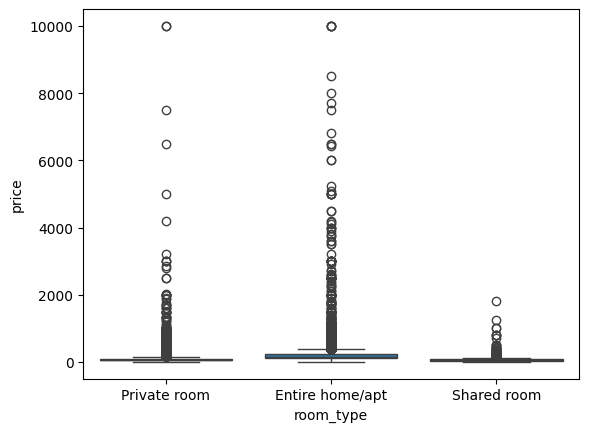

In [13]:
sns.boxplot(data = df , x = 'room_type' , y = 'price')

<Axes: >

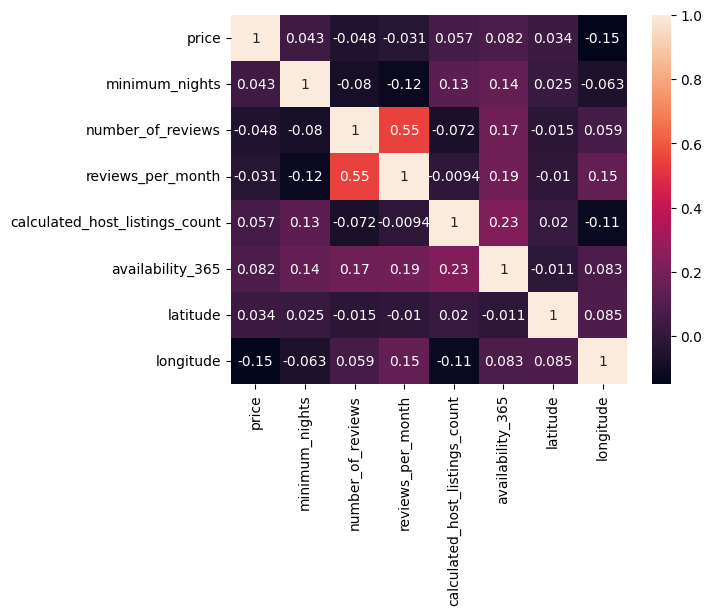

In [14]:
corr = df[numerical_col + ['latitude' , 'longitude']].corr()
sns.heatmap(corr , annot = True)

<Axes: xlabel='longitude', ylabel='latitude'>

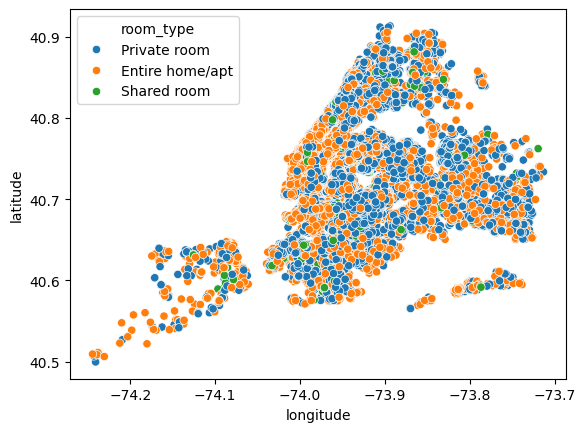

In [15]:
sns.scatterplot(data = df , x = 'longitude' , y = 'latitude' , hue = 'room_type')

In [16]:
# droping unwanted columns
df_clean = df.drop(columns = ['id', 'name', 'host_name', 'last_review'])

# filling missing values with zeroes
df_clean['reviews_per_month'] = df_clean['reviews_per_month'].fillna(0)

In [17]:
# cap extreame outlier instead of deleting rows
price_cap = df_clean['price'].quantile(0.99)
night_cap = df_clean['minimum_nights'].quantile(0.99)

df_clean = df_clean[(df_clean['price'] < price_cap) &
                    (df_clean['minimum_nights']< night_cap)]


In [18]:
x = df_clean.drop(columns = ['room_type'])
y = df_clean['room_type']

In [19]:
from sklearn.model_selection import train_test_split
x_train , x_test , y_train , y_test = train_test_split(x , y , test_size = 0.2 , random_state = 42 , stratify = y)

In [20]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder , StandardScaler , PowerTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [21]:
numerical_col = ["price" , "minimum_nights" , "number_of_reviews" ,
                 "reviews_per_month" , "calculated_host_listings_count" ,
                 "availability_365",'latitude','longitude']

categorical_col = ['neighbourhood_group' , 'neighbourhood' ]

# pipeline for numerical_column

numerical_pipeline = Pipeline(steps=[
    ('imputer' , SimpleImputer(strategy = 'median')),
    ('scaler' , StandardScaler())
])

# pipeline for categorical column

categorical_pipeline = Pipeline(steps=[
    ('imputer' , SimpleImputer(strategy = 'most_frequent')),
    ('onehot' , OneHotEncoder(handle_unknown='ignore'))
])

preprossessing = ColumnTransformer(transformers=[
    ('num' , numerical_pipeline , numerical_col),
    ('cat' , categorical_pipeline , categorical_col)
])

preprossessing

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['price', 'minimum_nights',
                                  'number_of_reviews', 'reviews_per_month',
                                  'calculated_host_listings_count',
                                  'availability_365', 'latitude',
                                  'longitude']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['neighbourhood_group', 'neighbourhood'])])

In [22]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier , GradientBoostingClassifier
from sklearn.model_selection import cross_val_score
import warnings


In [23]:
warnings.filterwarnings('ignore')

In [24]:
model = {
    'logistic_regression' : LogisticRegression(class_weight='balanced' , random_state=42),
    'decision_tree' : DecisionTreeClassifier(class_weight='balanced' , random_state=42),
    'random_forest' : RandomForestClassifier(class_weight='balanced' , random_state=42),
    'gradient_boosting' : GradientBoostingClassifier(random_state=42)
}


for name , model in model.items():
  pipe = Pipeline(steps=[
      ('preprossessing' , preprossessing),
      ('model' , model)
  ])

  acc = cross_val_score(pipe , x_train , y_train , cv = 3 , scoring = "accuracy")
  macrof1 = cross_val_score(pipe , x_train , y_train , cv = 3 , scoring = "f1_macro")

  print(f"{name} accuracy : {acc.mean()}")
  print(f"{name} macrof1 : {macrof1.mean()}")

logistic_regression accuracy : 0.6745435576421492
logistic_regression macrof1 : 0.5344973080021627
decision_tree accuracy : 0.7872717788210747
decision_tree macrof1 : 0.6567351198290194
random_forest accuracy : 0.8522170057381325
random_forest macrof1 : 0.7155637226431076
gradient_boosting accuracy : 0.8529733959311424
gradient_boosting macrof1 : 0.7122758398794818


In [25]:
from sklearn.model_selection import RandomizedSearchCV
best_pipeline = Pipeline(steps=[
      ('preprossessing' , preprossessing),
      ('model' , RandomForestClassifier(class_weight='balanced' , random_state=42))
  ])

parameter_dstribution = {
    'model__n_estimators' : [100 , 200 , 150 , 300],
    'model__max_depth' : [8 , 12 , 15 , 20 , None],
    'model__min_samples_split' : [2 , 5 , 10],

}

search = RandomizedSearchCV(
    estimator = best_pipeline,
    param_distributions= parameter_dstribution,
    n_iter= 10,
    cv = 3,
    scoring= 'f1_macro',
    random_state = 42
)
search.fit(x_train , y_train)


RandomizedSearchCV(cv=3,
                   estimator=Pipeline(steps=[('preprossessing',
                                              ColumnTransformer(transformers=[('num',
                                                                               Pipeline(steps=[('imputer',
                                                                                                SimpleImputer(strategy='median')),
                                                                                               ('scaler',
                                                                                                StandardScaler())]),
                                                                               ['price',
                                                                                'minimum_nights',
                                                                                'number_of_reviews',
                                                                                'reviews_per_month',
                                                                                'calculated_host_listings_count',
                                                                                'availability_365',
                                                                                'latitude',
                                                                                'longitude']),
                                                                              ('cat',
                                                                               Pi...
                                                                                                SimpleImputer(strategy='most_frequent')),
                                                                                               ('onehot',
                                                                                                OneHotEncoder(handle_unknown='ignore'))]),
                                                                               ['neighbourhood_group',
                                                                                'neighbourhood'])])),
                                             ('model',
                                              RandomForestClassifier(class_weight='balanced',
                                                                     random_state=42))]),
                   param_distributions={'model__max_depth': [8, 12, 15, 20,
                                                             None],
                                        'model__min_samples_split': [2, 5, 10],
                                        'model__n_estimators': [100, 200, 150,
                                                                300]},
                   random_state=42, scoring='f1_macro')

In [26]:
print(f"Best parameter : {search.best_params_}")
print(f"Best score : {search.best_score_}")

Best parameter : {'model__n_estimators': 200, 'model__min_samples_split': 10, 'model__max_depth': None}
Best score : 0.7327955615286837


In [28]:
from sklearn.metrics import accuracy_score , f1_score , confusion_matrix

best_pipeline = search.best_estimator_
y_pred = best_pipeline.predict(x_test)

print(f"Accuracy : {accuracy_score(y_test , y_pred)}")
print(f"F1 score : {f1_score(y_test , y_pred , average = 'macro')}")

Accuracy : 0.8582159624413146
F1 score : 0.7396110905662189


<Axes: >

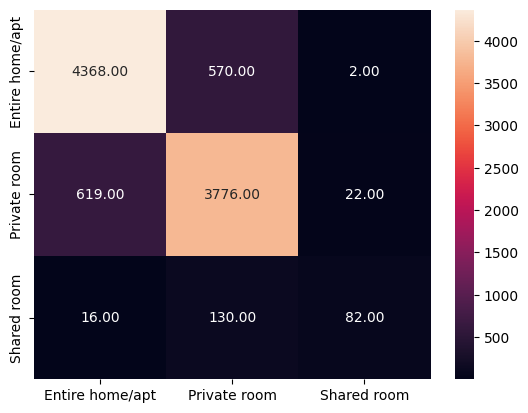

In [33]:
sns.heatmap(confusion_matrix(y_test , y_pred) , annot = True , fmt=".2f" , xticklabels=best_pipeline.classes_ , yticklabels=best_pipeline.classes_)

In [34]:
import joblib

joblib.dump(best_pipeline , "Model_pipeline.pkl")

['Model_pipeline.pkl']